# Soft Robotic Arm — Pouch Control and Circular Tracking

This notebook teaches you how to:

1. command all twenty pouches independently;
2. read the five pouch pressures in every segment;
3. observe the arm tip position and velocity; and
4. use a PD controller to track a circular tip trajectory.

The final example is a starting point: tune the gains and pouch distribution,
then improve or replace the controller.


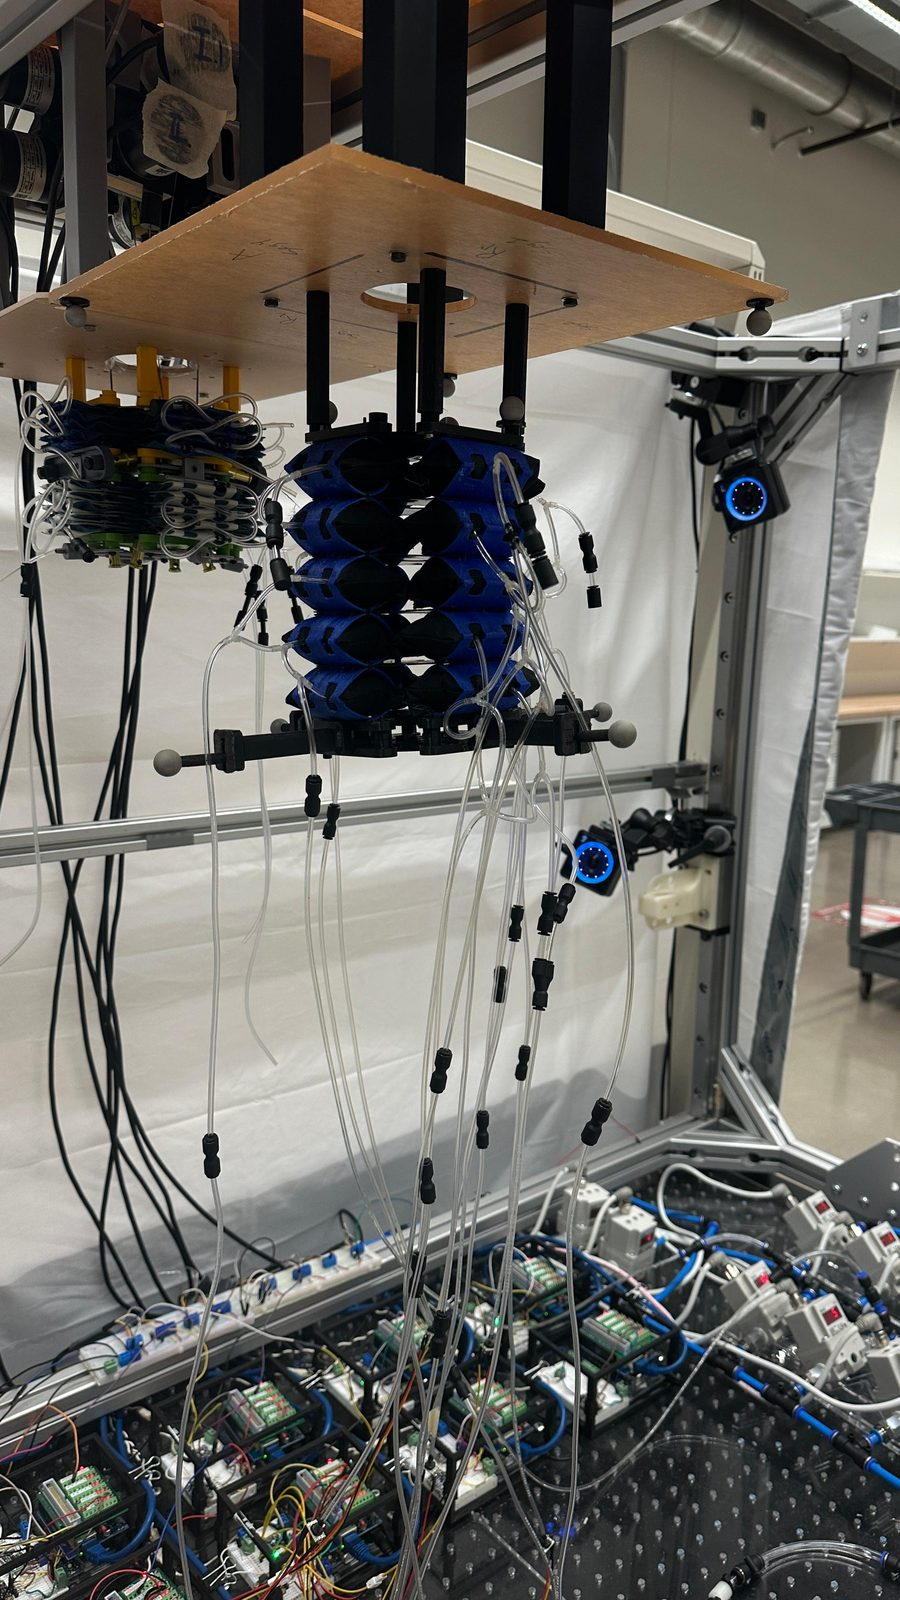

*Physical arm: four blue fabric columns, five pouch levels, OptiTrack tip frame.*

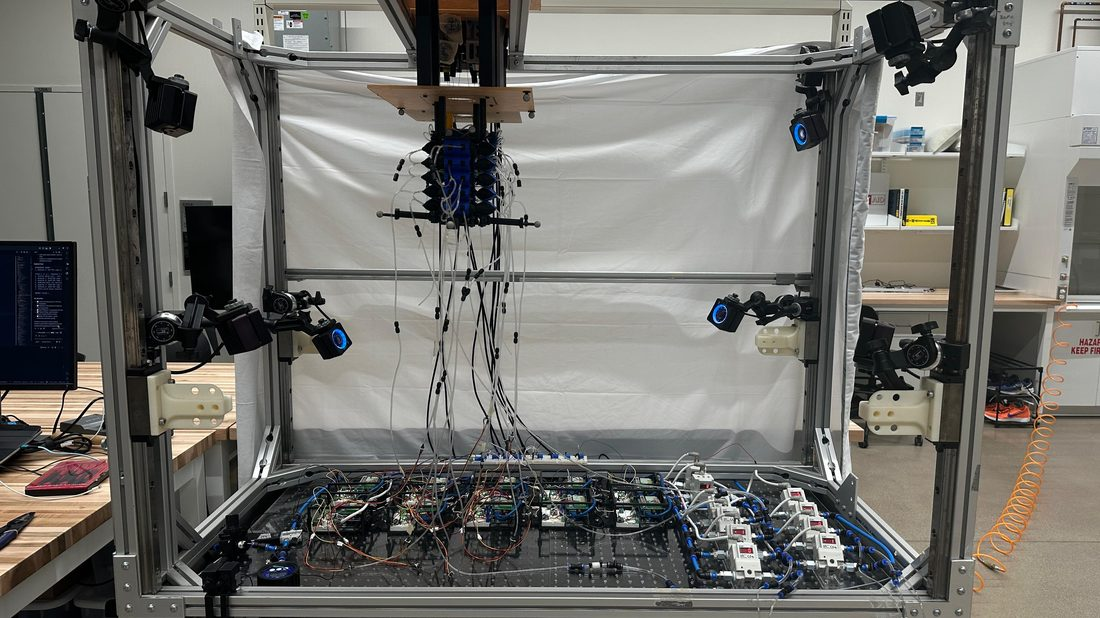

*Full rig: arm at centre, six OptiTrack cameras, pressure regulators and DAQ hardware.*

## 1 — Install the arm library

Run this once in a new Google Colab runtime. It installs the arm model, MuJoCo,
NumPy, and Matplotlib directly from GitHub. If you previously ran an older
version in the same runtime, the next cell clears that cached version before
loading the current package.


In [ ]:
%pip install -q --upgrade --no-cache-dir "soft-robotic-arm[coursework] @ git+https://github.com/Jeevan-HM/Soft-Robotic-Arm.git@simulation#subdirectory=mujoco"


## 2 — Segment and pouch indexing

A pouch command has shape `(4, 5)`. Rows select S1–S4 and columns select
P1–P5. For example, `command[1, 2]` addresses P3 in S2.

| Row | Segment | Tip tendency |
|---:|---|---|
| `0` | S1 | +x |
| `1` | S2 | +y |
| `2` | S3 | −x |
| `3` | S4 | −y |


In [ ]:
import os
import sys
from importlib.metadata import version

# Google Colab is Linux. Set the renderer before importing MuJoCo.
os.environ["MUJOCO_GL"] = "egl"
os.environ["PYOPENGL_PLATFORM"] = "egl"

# Colab can retain an already-imported package after %pip upgrades it.
# Remove only this package from the import cache, then load the installed copy.
for module_name in tuple(sys.modules):
    if module_name == "soft_robotic_arm" or module_name.startswith("soft_robotic_arm."):
        del sys.modules[module_name]

import matplotlib.pyplot as plt
import numpy as np
import soft_robotic_arm
from soft_robotic_arm import make_sim

EXPECTED_VERSION = "0.4.0"
installed_version = version("soft-robotic-arm")
if installed_version != EXPECTED_VERSION or soft_robotic_arm.__version__ != EXPECTED_VERSION:
    raise RuntimeError(
        f"Expected soft-robotic-arm {EXPECTED_VERSION}, but loaded "
        f"{soft_robotic_arm.__version__} (installed: {installed_version}). "
        "Choose Runtime > Restart session, then Run all."
    )

CONTROL_HZ = 100.0
MAX_PRESSURE_PSI = 9.0

sim = make_sim(control_hz=CONTROL_HZ, seed=0)
obs = sim.reset()

print(f"soft-robotic-arm version: {installed_version}")
print("Simulator ready")
print("Command rows: S1, S2, S3, S4; columns: P1, P2, P3, P4, P5")
print("Tip position [m]:", np.round(obs["tip_pos"], 4))
print("Pouch-pressure array shape:", obs["pouch_pressures"].shape)


## 3 — Command every pouch and read its pressure

Use a `(4, 5)` array to command the twenty pouches independently:

```python
command[segment_index, pouch_index] = pressure_psi
obs = sim.step(command)
```

Rows are S1–S4; columns are P1–P5. `sim.step()` also accepts a `(4,)` segment
vector and broadcasts each segment value to its five pouches. Keep every
command between 0 and 9 psi.

| Observation | Shape | Meaning |
|---|---:|---|
| `obs["tip_pos"]` | `(3,)` | tip `[x, y, z]` position in metres |
| `obs["tip_vel"]` | `(3,)` | tip velocity in m/s |
| `obs["pouch_pressures"]` | `(4, 5)` | measured pressure of every pouch |
| `obs["segment_pressures"]` | `(4,)` | mean measured pressure of each segment |
| `obs["time"]` | scalar | simulation time in seconds |


In [ ]:
# Start every pouch at 2 psi, then command only P3 in S2 to 6 psi.
command = np.full((4, 5), 2.0)
command[1, 2] = 6.0

for _ in range(int(CONTROL_HZ)):
    obs = sim.step(command)

print("Commanded pouch pressures [psi]:\n", command)
print("Measured pouch pressures [psi]:\n", np.round(obs["pouch_pressures"], 3))
print("Measured segment means [psi]:", np.round(obs["segment_pressures"], 3))
print("Tip position [m]:", np.round(obs["tip_pos"], 4))


### Try any pouch

Choose `TEST_SEGMENT` from 0–3 and `TEST_POUCH` from 0–4. The cell holds every
other pouch at 2 psi, raises only the selected pouch, and plots its response.


In [ ]:
TEST_SEGMENT = 0  # 0=S1, 1=S2, 2=S3, 3=S4
TEST_POUCH = 0    # 0=P1, 1=P2, 2=P3, 3=P4, 4=P5

sim = make_sim(control_hz=CONTROL_HZ, seed=1)
obs = sim.reset()
baseline = np.full((4, 5), 2.0)

for _ in range(int(3.0 * CONTROL_HZ)):
    obs = sim.step(baseline)
home = obs["tip_pos"].copy()

command = baseline.copy()
command[TEST_SEGMENT, TEST_POUCH] = 6.0

times, tips, measured = [], [], []
for _ in range(int(4.0 * CONTROL_HZ)):
    obs = sim.step(command)
    times.append(obs["time"])
    tips.append(obs["tip_pos"].copy())
    measured.append(obs["pouch_pressures"].copy())

times = np.asarray(times) - times[0]
tips = np.asarray(tips)
measured = np.asarray(measured)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(times, (tips[:, 0] - home[0]) * 1000, label="Δx")
axes[0].plot(times, (tips[:, 1] - home[1]) * 1000, label="Δy")
axes[0].set(xlabel="Time [s]", ylabel="Tip change [mm]", title="Tip response")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for pouch in range(5):
    axes[1].plot(times, measured[:, TEST_SEGMENT, pouch], label=f"P{pouch + 1}")
axes[1].set(xlabel="Time [s]", ylabel="Measured pressure [psi]", title=f"S{TEST_SEGMENT + 1} pouch pressures")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4 — PD control for a circular trajectory

The reference is a circle in the x–y plane. The controller uses position error
and velocity error:

`u = Kp (position_reference − position) + Kd (velocity_reference − velocity)`

The x–y control effort is projected onto S1–S4. A five-value pouch profile then
distributes that effort independently across P1–P5, producing a `(4, 5)` command.


In [ ]:
class CircularPDController:
    """Example PD controller that returns twenty pouch commands."""

    def __init__(self, radius_m=0.015, period_s=10.0, kp=500.0, kd=20.0):
        self.radius = radius_m
        self.omega = 2.0 * np.pi / period_s
        self.kp = kp
        self.kd = kd
        self.baseline_psi = 4.5
        self.center_xy = None
        # Rows S1--S4 point +x, +y, -x, -y.
        self.segment_directions = np.array([[1., 0.], [0., 1.], [-1., 0.], [0., -1.]])
        # P1--P5 can receive different commands. Tune this distribution.
        self.pouch_profile = np.array([0.70, 0.85, 1.00, 1.15, 1.30])

    def reference(self, t):
        angle = self.omega * t
        position = self.center_xy + self.radius * np.array([np.cos(angle), np.sin(angle)])
        velocity = self.radius * self.omega * np.array([-np.sin(angle), np.cos(angle)])
        return position, velocity

    def compute(self, t: float, obs: dict) -> np.ndarray:
        if self.center_xy is None:
            self.center_xy = obs["tip_pos"][:2].copy()

        target_pos, target_vel = self.reference(t)
        position_error = target_pos - obs["tip_pos"][:2]
        velocity_error = target_vel - obs["tip_vel"][:2]
        xy_effort = self.kp * position_error + self.kd * velocity_error

        segment_effort = self.segment_directions @ xy_effort
        command = self.baseline_psi + segment_effort[:, None] * self.pouch_profile[None, :]
        return np.clip(command, 0.0, MAX_PRESSURE_PSI)


## 5 — Track and plot the circle

The loop advances the simulator, records the desired and measured paths, and
reports planar tracking RMSE. The controller must return a finite `(4, 5)`
pouch-pressure matrix on every call.


In [ ]:
sim = make_sim(control_hz=CONTROL_HZ, seed=2)
controller = CircularPDController()
obs = sim.reset()

RUN_TIME_S = 20.0
times, references, tips, commands = [], [], [], []

for _ in range(int(RUN_TIME_S * CONTROL_HZ)):
    command = np.asarray(controller.compute(obs["time"], obs), dtype=float)
    if command.shape != (4, 5) or not np.all(np.isfinite(command)):
        raise ValueError("Controller must return a finite (4, 5) pouch-pressure matrix")
    target_pos, _ = controller.reference(obs["time"])
    obs = sim.step(command)

    times.append(obs["time"])
    references.append(target_pos.copy())
    tips.append(obs["tip_pos"][:2].copy())
    commands.append(command.copy())

times = np.asarray(times)
references = np.asarray(references)
tips = np.asarray(tips)
commands = np.asarray(commands)
errors = np.linalg.norm(references - tips, axis=1)
rmse_mm = 1000.0 * np.sqrt(np.mean(errors**2))
print(f"Planar tracking RMSE: {rmse_mm:.2f} mm")
print("Command history shape:", commands.shape, "= time × segment × pouch")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(references[:, 0] * 1000, references[:, 1] * 1000, "--", label="reference")
axes[0].plot(tips[:, 0] * 1000, tips[:, 1] * 1000, label="tip")
axes[0].set(xlabel="x [mm]", ylabel="y [mm]", title="Circular tracking")
axes[0].set_aspect("equal")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(times, errors * 1000)
axes[1].set(xlabel="Time [s]", ylabel="Planar error [mm]", title="Tracking error")
axes[1].grid(True, alpha=0.3)

for pouch in range(5):
    axes[2].plot(times, commands[:, 0, pouch], label=f"S1 P{pouch + 1}")
axes[2].set(xlabel="Time [s]", ylabel="Command [psi]", title="Independent S1 pouch commands")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Student tasks

- Tune `kp` and `kd` and explain their effect on tracking.
- Change the circle radius or period and compare the RMSE.
- Change `pouch_profile` to investigate how P1–P5 affect the motion.
- Keep every command between 0 and 9 psi.
- Explain how the `(4, 5)` command maps to the twenty pouches.
